# 03 — Model Training
**Brugada-HUCA ECG Dataset**

This notebook trains two model families and saves their artifacts:

| Stage | Models |
|---|---|
| **Classical ML** | Logistic Regression (baseline), Random Forest (tuned) |
| **Deep Learning** | 1D ResNet (primary model) |

Both are evaluated on the **validation set** here.  
Final test-set evaluation is in `04_evaluation.ipynb`.

## 0 — Setup

In [ ]:
import sys, pickle
from pathlib import Path

_cwd = Path().resolve()
ROOT = next(
    (p for p in [_cwd, *_cwd.parents] if (p / 'src' / 'config.py').exists()),
    _cwd,
)
sys.path.insert(0, str(ROOT / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

import config as cfg
from preprocessing import load_processed, compute_pos_weight
from features import extract_batch
from dataset import ECGDataset, make_loaders
from models import ResNet1D, LSTM1D, BiLSTM1D, RNN1D, Simple1DCNN
from train import run_training, load_checkpoint
from evaluate import plot_training_curves, compute_metrics, predict_dl

REPORTS = ROOT / 'reports'
REPORTS.mkdir(exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
torch.manual_seed(cfg.RANDOM_SEED)
np.random.seed(cfg.RANDOM_SEED)

Device: cpu


## 1 — Load Processed Data

In [2]:
X_train, y_train, ids_train = load_processed('train', cfg.DATA_PROCESSED)
X_val,   y_val,   ids_val   = load_processed('val',   cfg.DATA_PROCESSED)
X_test,  y_test,  ids_test  = load_processed('test',  cfg.DATA_PROCESSED)

print(f'Train: {X_train.shape}  Brugada={( y_train==1).sum()}  Normal={(y_train==0).sum()}')
print(f'Val  : {X_val.shape}   Brugada={(y_val==1).sum()}  Normal={(y_val==0).sum()}')
print(f'Test : {X_test.shape}  Brugada={(y_test==1).sum()}  Normal={(y_test==0).sum()}')

Train: (253, 12, 1200)  Brugada=53  Normal=200
Val  : (55, 12, 1200)   Brugada=11  Normal=44
Test : (55, 12, 1200)  Brugada=12  Normal=43


---
## Part A — Classical ML
### A1 — Feature Extraction

In [ ]:
# Cache features to disk so re-running is fast
feat_cache = cfg.DATA_PROCESSED / 'features_train.parquet'

if feat_cache.exists():
    print('Loading cached features...')
    df_train_feat = pd.read_parquet(feat_cache)
else:
    print('Extracting features (this may take a few minutes)...')
    df_train_feat = extract_batch(X_train, ids=ids_train)
    df_train_feat.to_parquet(feat_cache)

feat_cache_val = cfg.DATA_PROCESSED / 'features_val.parquet'
if feat_cache_val.exists():
    df_val_feat = pd.read_parquet(feat_cache_val)
else:
    df_val_feat = extract_batch(X_val, ids=ids_val)
    df_val_feat.to_parquet(feat_cache_val)

feat_cache_test = cfg.DATA_PROCESSED / 'features_test.parquet'
if feat_cache_test.exists():
    df_test_feat = pd.read_parquet(feat_cache_test)
else:
    df_test_feat = extract_batch(X_test, ids=ids_test)
    df_test_feat.to_parquet(feat_cache_test)

print(f'\nFeature matrix shape (train): {df_train_feat.shape}')
df_train_feat.head(3)

Loading cached features...

Feature matrix shape (train): (253, 200)


,i_mean,i_std,i_min,i_max,i_range,i_abs_mean,i_rms,i_skew,i_kurtosis,i_low_power,...,v3_st_slope,v3_coved_ratio,hr_mean,hr_std,rr_mean,rr_std,sdnn,rmssd,pnn50,n_rpeaks
1180702,-4.768371e-09,1.0,-3.356033,5.632895,8.988928,0.605236,1.0,2.225428,10.142344,0.288022,...,-0.013790,1.190270,65.005402,1.239034,0.923333,0.017480,0.017480,0.021950,0.0,13
1424148,-3.973643e-09,1.0,-3.482592,4.083667,7.566258,0.676234,1.0,0.409470,3.376095,0.224913,...,-0.043306,1.475606,102.251684,0.986829,0.586842,0.005669,0.005669,0.006667,0.0,20
450733,-2.384186e-09,1.0,-2.351643,5.885669,8.237312,0.641885,1.0,2.828716,11.821709,0.235876,...,-0.115616,1.614786,72.570218,0.937101,0.826923,0.010659,0.010659,0.016330,0.0,14


In [4]:
from sklearn.preprocessing import StandardScaler

# Standardize features (fit on train only)
scaler = StandardScaler()
X_tr_ml = scaler.fit_transform(df_train_feat.values)
X_vl_ml = scaler.transform(df_val_feat.values)
X_te_ml = scaler.transform(df_test_feat.values)

# Save scaler for inference
with open(cfg.MODELS_DIR / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('Feature shapes:', X_tr_ml.shape, X_vl_ml.shape, X_te_ml.shape)

Feature shapes: (253, 200) (55, 200) (55, 200)


### A2 — Logistic Regression Baseline

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

n_pos = (y_train == 1).sum()
n_neg = (y_train == 0).sum()
cw = {0: 1.0, 1: n_neg / n_pos}   # class weights mirror pos_weight

lr = LogisticRegression(
    max_iter=2000, class_weight=cw, solver='lbfgs',
    C=0.1, random_state=cfg.RANDOM_SEED
)

# 5-fold stratified cross-validation on TRAIN set
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=cfg.RANDOM_SEED)
cv_auroc_lr = cross_val_score(lr, X_tr_ml, y_train, cv=skf, scoring='roc_auc')
print(f'LogReg CV AUROC: {cv_auroc_lr.mean():.3f} ± {cv_auroc_lr.std():.3f}')

# Fit on full train set
lr.fit(X_tr_ml, y_train)

# Save
cfg.MODELS_DIR.mkdir(parents=True, exist_ok=True)
with open(cfg.MODELS_DIR / 'lr_best.pkl', 'wb') as f:
    pickle.dump(lr, f)

# Validate
lr_prob_val = lr.predict_proba(X_vl_ml)[:, 1]
lr_metrics_val = compute_metrics(y_val, lr_prob_val)
print('\nLogReg — Val metrics:')
for k, v in lr_metrics_val.items():
    print(f'  {k}: {v}')

LogReg CV AUROC: 0.791 ± 0.094

LogReg — Val metrics:
  auroc: 0.7748
  auprc: 0.596
  accuracy: 0.8
  sensitivity: 0.5455
  specificity: 0.8636
  precision: 0.5
  f1: 0.5217
  threshold: 0.5
  tp: 6
  tn: 38
  fp: 6
  fn: 5


### A3 — Random Forest + GridSearchCV

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 400],
    'max_depth':    [None, 15, 25],
    'min_samples_leaf': [1, 2],
}

rf_base = RandomForestClassifier(
    class_weight='balanced', random_state=cfg.RANDOM_SEED, n_jobs=-1
)

gs = GridSearchCV(
    rf_base, param_grid, cv=skf, scoring='roc_auc',
    n_jobs=-1, verbose=1, refit=True
)
gs.fit(X_tr_ml, y_train)

print(f'\nBest RF params: {gs.best_params_}')
print(f'Best CV AUROC : {gs.best_score_:.3f}')

rf = gs.best_estimator_

# Save RF
cfg.MODELS_DIR.mkdir(parents=True, exist_ok=True)
with open(cfg.MODELS_DIR / 'rf_best.pkl', 'wb') as f:
    pickle.dump(rf, f)

rf_prob_val = rf.predict_proba(X_vl_ml)[:, 1]
rf_metrics_val = compute_metrics(y_val, rf_prob_val)
print('\nRandom Forest — Val metrics:')
for k, v in rf_metrics_val.items():
    print(f'  {k}: {v}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best RF params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 400}
Best CV AUROC : 0.865

Random Forest — Val metrics:
  auroc: 0.8388
  auprc: 0.6464
  accuracy: 0.8364
  sensitivity: 0.1818
  specificity: 1.0
  precision: 1.0
  f1: 0.3077
  threshold: 0.5
  tp: 2
  tn: 44
  fp: 0
  fn: 9


### A4 — Feature Importance (top 20)

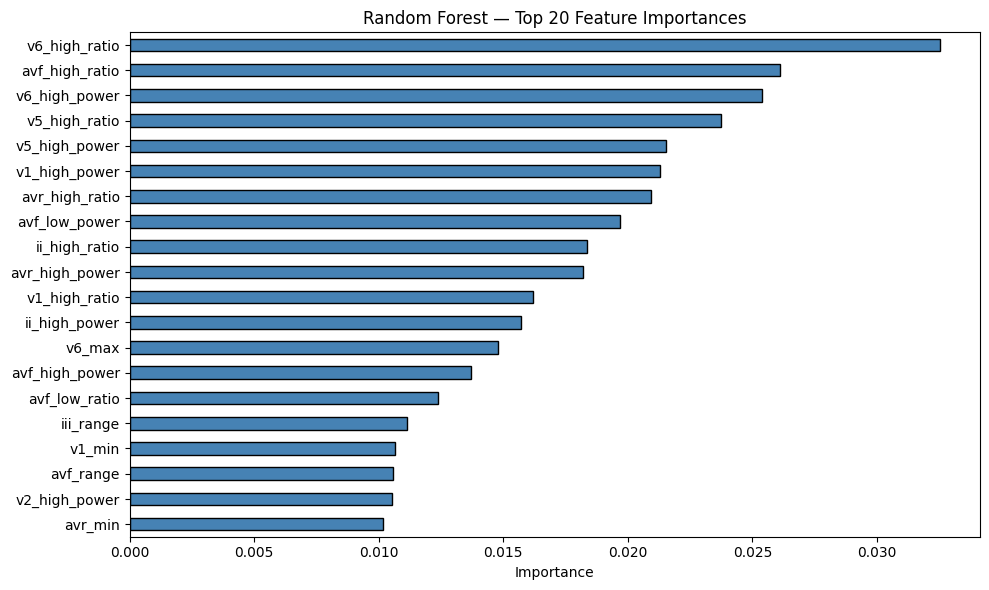

In [7]:
importances = pd.Series(rf.feature_importances_, index=df_train_feat.columns)
top20 = importances.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 6))
top20[::-1].plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Importance')
ax.set_title('Random Forest — Top 20 Feature Importances')
plt.tight_layout()
plt.savefig(REPORTS / 'rf_feature_importance.png', dpi=150)
plt.show()

---
## Part B — Deep Learning: 1D ResNet
### B1 — DataLoaders

In [3]:
splits = {
    'X_train': X_train, 'y_train': y_train, 'ids_train': ids_train,
    'X_val':   X_val,   'y_val':   y_val,   'ids_val':   ids_val,
    'X_test':  X_test,  'y_test':  y_test,  'ids_test':  ids_test,
}

loaders = make_loaders(splits, batch_size=cfg.BATCH_SIZE)

print('DataLoader sizes:')
for name, dl in loaders.items():
    print(f'  {name}: {len(dl.dataset)} samples, {len(dl)} batches')

DataLoader sizes:
  train: 253 samples, 8 batches
  val: 55 samples, 2 batches
  test: 55 samples, 2 batches


### B2 — Model Architecture

In [9]:
model = ResNet1D(
    n_leads=cfg.N_LEADS,
    base_channels=64,
    kernel_size=7,
    dropout=0.2,
).to(DEVICE)

print(f'Parameters: {model.count_parameters():,}')

# Dry run to verify output shape
with torch.no_grad():
    dummy = torch.zeros(2, cfg.N_LEADS, cfg.N_SAMPLES).to(DEVICE)
    out   = model(dummy)
    print(f'Output shape: {out.shape}  (expected: [2, 1])')

Parameters: 8,737,921
Output shape: torch.Size([2, 1])  (expected: [2, 1])


### B3 — Loss, Optimizer, Scheduler

In [10]:
pos_w = compute_pos_weight(y_train)
print(f'pos_weight = {pos_w:.2f}')

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_w, dtype=torch.float32).to(DEVICE)
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=cfg.LEARNING_RATE,
    weight_decay=cfg.WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=cfg.NUM_EPOCHS, eta_min=1e-5
)

print('Optimizer:', optimizer)
print('Scheduler: CosineAnnealingLR')

pos_weight = 3.77
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Scheduler: CosineAnnealingLR


### B4 — Training Loop

In [11]:
CHECKPOINT = cfg.MODELS_DIR / 'best_resnet1d.pt'

history = run_training(
    model         = model,
    train_loader  = loaders['train'],
    val_loader    = loaders['val'],
    optimizer     = optimizer,
    criterion     = criterion,
    scheduler     = scheduler,
    device        = DEVICE,
    num_epochs    = cfg.NUM_EPOCHS,
    patience      = cfg.PATIENCE,
    checkpoint_path = CHECKPOINT,
    verbose       = True,
)

print(f'\nBest val AUROC: {max(history["val_auroc"]):.4f} at epoch {int(np.argmax(history["val_auroc"]))+1}')

Epoch   1/50 | Train loss=1.7740 acc=0.557 AUROC=0.548 | Val   loss=14.4810 acc=0.800 AUROC=0.663 | 8.5s
Epoch   2/50 | Train loss=1.1399 acc=0.664 AUROC=0.755 | Val   loss=5.2794 acc=0.200 AUROC=0.467 | 8.4s
Epoch   3/50 | Train loss=0.9767 acc=0.783 AUROC=0.828 | Val   loss=1.5134 acc=0.745 AUROC=0.814 | 8.0s
Epoch   4/50 | Train loss=0.6015 acc=0.874 AUROC=0.926 | Val   loss=17.7401 acc=0.200 AUROC=0.579 | 8.5s
Epoch   5/50 | Train loss=0.7057 acc=0.870 AUROC=0.933 | Val   loss=2.7908 acc=0.855 AUROC=0.870 | 8.2s
Epoch   6/50 | Train loss=0.4670 acc=0.877 AUROC=0.948 | Val   loss=1.2295 acc=0.909 AUROC=0.917 | 8.7s
Epoch   7/50 | Train loss=0.4104 acc=0.929 AUROC=0.969 | Val   loss=1.2400 acc=0.891 AUROC=0.950 | 9.2s
Epoch   8/50 | Train loss=0.3280 acc=0.953 AUROC=0.980 | Val   loss=3.4150 acc=0.800 AUROC=0.853 | 8.3s
Epoch   9/50 | Train loss=0.3650 acc=0.917 AUROC=0.978 | Val   loss=3.2867 acc=0.473 AUROC=0.839 | 8.3s
Epoch  10/50 | Train loss=0.2674 acc=0.937 AUROC=0.982 | Val  

### B5 — Training Curves

In [4]:
from evaluate import plot_training_curves

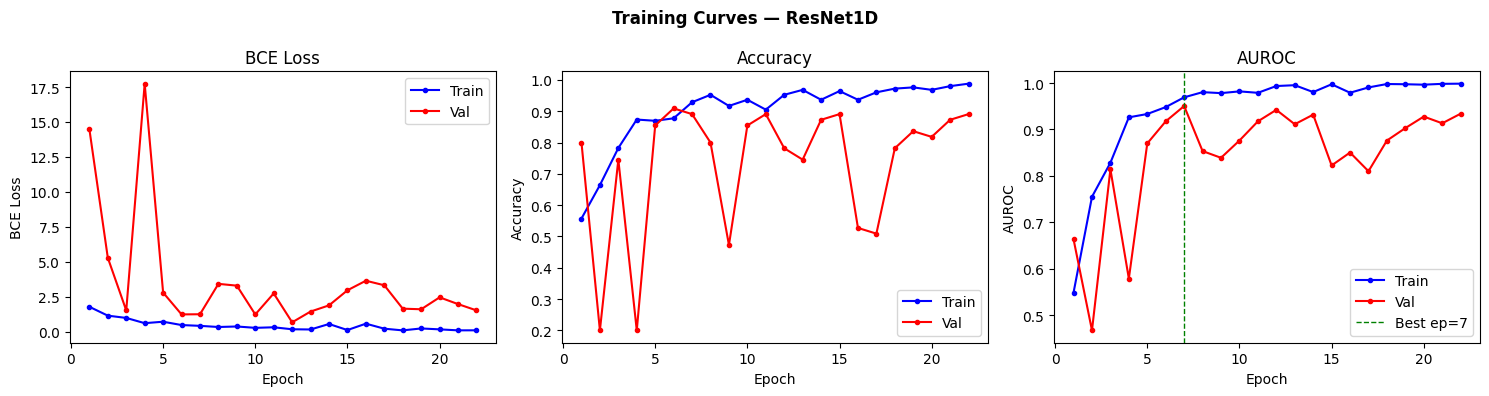

In [12]:
from evaluate import plot_training_curves

plot_training_curves(history, save_path=REPORTS / 'training_curves.png')

### B6 — Reload Best Checkpoint and Validate

In [13]:
best_epoch = load_checkpoint(CHECKPOINT, model)
print(f'Loaded best checkpoint from epoch {best_epoch}')

y_true_val, y_prob_val_dl = predict_dl(model, loaders['val'], device=DEVICE)
dl_metrics_val = compute_metrics(y_true_val, y_prob_val_dl)

print('\n1D ResNet — Val metrics:')
for k, v in dl_metrics_val.items():
    print(f'  {k}: {v}')

Loaded best checkpoint from epoch 12

1D ResNet — Val metrics:
  auroc: 0.9421
  auprc: 0.8573
  accuracy: 0.7818
  sensitivity: 0.9091
  specificity: 0.75
  precision: 0.4762
  f1: 0.625
  threshold: 0.5
  tp: 10
  tn: 33
  fp: 11
  fn: 1


## Summary — Validation Comparison

Quick look at key metrics before full test evaluation.

In [14]:
from evaluate import compare_models

val_results = {
    'LogReg':    lr_metrics_val,
    'RandomForest': rf_metrics_val,
    'ResNet1D':  dl_metrics_val,
}

df_val_cmp = compare_models(val_results)
print('\nValidation Set — Model Comparison:')
display(df_val_cmp)


Validation Set — Model Comparison:


,AUROC,AUPRC,Sensitivity,Specificity,Precision,F1,Accuracy
Model,,,,,,,
LogReg,0.7748,0.5960,0.5455,0.8636,0.5000,0.5217,0.8000
RandomForest,0.8388,0.6464,0.1818,1.0000,1.0000,0.3077,0.8364
ResNet1D,0.9421,0.8573,0.9091,0.7500,0.4762,0.6250,0.7818


In [15]:
# Save val probabilities for notebook 04
import pickle
val_preds = {
    'LogReg':       {'y_true': y_val,      'y_prob': lr_prob_val},
    'RandomForest': {'y_true': y_val,      'y_prob': rf_prob_val},
    'ResNet1D':     {'y_true': y_true_val, 'y_prob': y_prob_val_dl},
}
with open(cfg.MODELS_DIR / 'val_predictions.pkl', 'wb') as f:
    pickle.dump(val_preds, f)

print('Saved val predictions to models/val_predictions.pkl')
print('Proceed to 04_evaluation.ipynb for test-set evaluation.')

Saved val predictions to models/val_predictions.pkl
Proceed to 04_evaluation.ipynb for test-set evaluation.


In [ ]:
import torch
import torch.nn as nn


class ConvBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=7, stride=1, padding=3, dropout=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, stride=stride, padding=padding, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.block(x)


class CNN1D(nn.Module):
    def __init__(self, n_leads=12, base_channels=64, n_classes=1, dropout=0.2):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(n_leads, base_channels, kernel_size=15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(base_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=3, stride=2, padding=1),
        )

        self.conv1 = ConvBlock1D(base_channels, base_channels, kernel_size=7, stride=1, padding=3, dropout=dropout)
        self.conv2 = ConvBlock1D(base_channels, base_channels*2, kernel_size=7, stride=2, padding=3, dropout=dropout)
        self.conv3 = ConvBlock1D(base_channels*2, base_channels*4, kernel_size=7, stride=2, padding=3, dropout=dropout)

        self.gap = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Flatten(),
            nn.Linear(base_channels*4, n_classes),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.gap(x)
        return self.head(x)


# Instantiate and dry-run check
cnn_model = CNN1D(n_leads=cfg.N_LEADS, base_channels=64, n_classes=1, dropout=0.2).to(DEVICE)
print(f'CNN params: {sum(p.numel() for p in cnn_model.parameters() if p.requires_grad):,}')

with torch.no_grad():
    dummy = torch.zeros(2, cfg.N_LEADS, cfg.N_SAMPLES).to(DEVICE)
    out = cnn_model(dummy)
    print(f'Output shape: {out.shape} (expected [2, 1])')

CNN params: 328,193
Output shape: torch.Size([2, 1]) (expected [2, 1])


In [22]:
# B3/B4 equivalent for Simple1DCNN
CHECKPOINT_CNN = cfg.MODELS_DIR / 'best_simple1dcnn.pt'

pos_w = compute_pos_weight(y_train)
criterion_cnn = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_w, dtype=torch.float32).to(DEVICE)
)

optimizer_cnn = torch.optim.AdamW(
    cnn_model.parameters(),
    lr=cfg.LEARNING_RATE,
    weight_decay=cfg.WEIGHT_DECAY,
)

scheduler_cnn = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_cnn,
    T_max=cfg.NUM_EPOCHS,
    eta_min=1e-5,
)

print('CNN criterion:', criterion_cnn)
print('CNN optimizer:', optimizer_cnn)
print('CNN scheduler: CosineAnnealingLR')

history_cnn = run_training(
    model=cnn_model,
    train_loader=loaders['train'],
    val_loader=loaders['val'],
    optimizer=optimizer_cnn,
    criterion=criterion_cnn,
    scheduler=scheduler_cnn,
    device=DEVICE,
    num_epochs=cfg.NUM_EPOCHS,
    patience=cfg.PATIENCE,
    checkpoint_path=CHECKPOINT_CNN,
    verbose=True,
)

print(
    f'\nCNN best val AUROC: {max(history_cnn["val_auroc"]):.4f} '
    f'at epoch {int(np.argmax(history_cnn["val_auroc"])) + 1}'
)

best_epoch_cnn = load_checkpoint(CHECKPOINT_CNN, cnn_model)
print(f'Loaded CNN checkpoint from epoch {best_epoch_cnn}')

y_true_val_cnn, y_prob_val_cnn = predict_dl(cnn_model, loaders['val'], device=DEVICE)
cnn_metrics_val = compute_metrics(y_true_val_cnn, y_prob_val_cnn)
print('\nSimple1DCNN — Val metrics:')
for k, v in cnn_metrics_val.items():
    print(f'  {k}: {v}')

CNN criterion: BCEWithLogitsLoss()
CNN optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
CNN scheduler: CosineAnnealingLR
Epoch   1/50 | Train loss=1.0016 acc=0.628 AUROC=0.704 | Val   loss=1.0018 acc=0.818 AUROC=0.791 | 0.8s
Epoch   2/50 | Train loss=0.6566 acc=0.791 AUROC=0.905 | Val   loss=2.0660 acc=0.200 AUROC=0.841 | 0.7s
Epoch   3/50 | Train loss=0.4587 acc=0.893 AUROC=0.960 | Val   loss=1.0938 acc=0.436 AUROC=0.837 | 0.8s
Epoch   4/50 | Train loss=0.4900 acc=0.870 AUROC=0.942 | Val   loss=0.8043 acc=0.655 AUROC=0.849 | 0.7s
Epoch   5/50 | Train loss=0.3442 acc=0.897 AUROC=0.979 | Val   loss=0.6962 acc=0.909 AUROC=0.901 | 0.7s
Epoch   6/50 | Train loss=0.2475 acc=0.953 AUROC=0.993 | Val   loss=0.7589 acc=0.855 AUROC=0.872 | 0.7s
Epoch   7/5

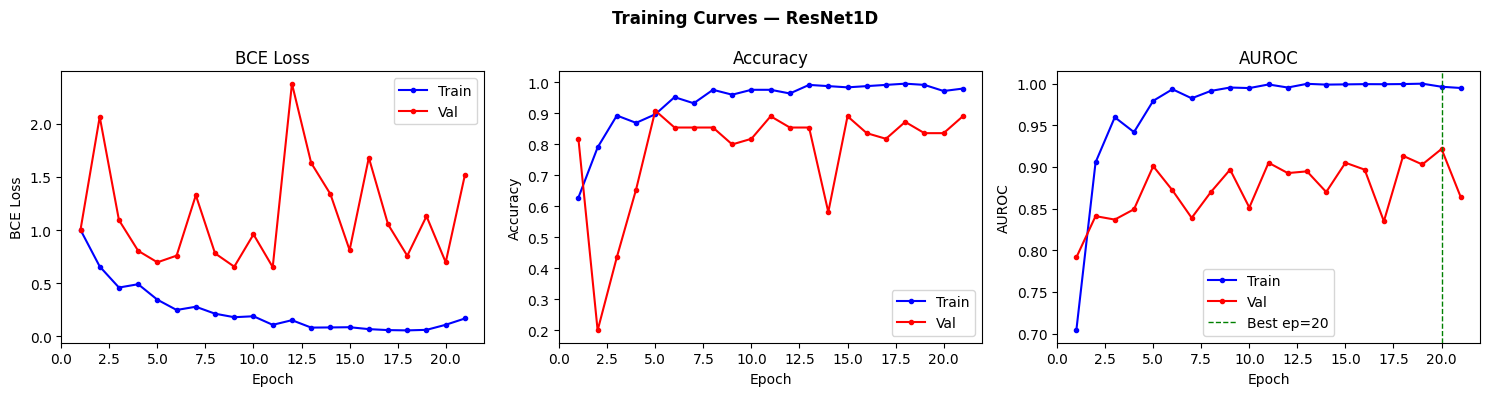

In [23]:
plot_training_curves(history_cnn, save_path=REPORTS / 'training_curves_cnn.png')

In [24]:
class LSTM1D(nn.Module):
    def __init__(self, n_leads=12, hidden_size=64, num_layers=2, dropout=0.2, n_classes=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_leads,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True,
        )
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, n_classes),
        )

    def forward(self, x):
        # x shape: [batch, n_leads, n_samples]
        # LSTM expects [batch, seq_len, input_size]
        x = x.transpose(1, 2)  # [batch, n_samples, n_leads]
        lstm_out, _ = self.lstm(x)  # [batch, n_samples, hidden_size]
        lstm_out = lstm_out.transpose(1, 2)  # [batch, hidden_size, n_samples]
        x = self.gap(lstm_out)  # [batch, hidden_size, 1]
        x = x.squeeze(-1)  # [batch, hidden_size]
        return self.head(x)


# Instantiate and dry-run check
lstm_model = LSTM1D(n_leads=cfg.N_LEADS, hidden_size=64, num_layers=2, dropout=0.2).to(DEVICE)
print(f'LSTM params: {sum(p.numel() for p in lstm_model.parameters() if p.requires_grad):,}')

with torch.no_grad():
    dummy = torch.zeros(2, cfg.N_LEADS, cfg.N_SAMPLES).to(DEVICE)
    out = lstm_model(dummy)
    print(f'Output shape: {out.shape} (expected [2, 1])')

LSTM params: 55,361
Output shape: torch.Size([2, 1]) (expected [2, 1])


In [25]:
# B3/B4 equivalent for LSTM1D
CHECKPOINT_LSTM = cfg.MODELS_DIR / 'best_lstm1d.pt'

pos_w = compute_pos_weight(y_train)
criterion_lstm = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_w, dtype=torch.float32).to(DEVICE)
)

optimizer_lstm = torch.optim.AdamW(
    lstm_model.parameters(),
    lr=cfg.LEARNING_RATE,
    weight_decay=cfg.WEIGHT_DECAY,
)

scheduler_lstm = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_lstm,
    T_max=cfg.NUM_EPOCHS,
    eta_min=1e-5,
)

print('LSTM criterion:', criterion_lstm)
print('LSTM optimizer:', optimizer_lstm)
print('LSTM scheduler: CosineAnnealingLR')

history_lstm = run_training(
    model=lstm_model,
    train_loader=loaders['train'],
    val_loader=loaders['val'],
    optimizer=optimizer_lstm,
    criterion=criterion_lstm,
    scheduler=scheduler_lstm,
    device=DEVICE,
    num_epochs=cfg.NUM_EPOCHS,
    patience=cfg.PATIENCE,
    checkpoint_path=CHECKPOINT_LSTM,
    verbose=True,
)

print(
    f'\nLSTM best val AUROC: {max(history_lstm["val_auroc"]):.4f} '
    f'at epoch {int(np.argmax(history_lstm["val_auroc"])) + 1}'
)

best_epoch_lstm = load_checkpoint(CHECKPOINT_LSTM, lstm_model)
print(f'Loaded LSTM checkpoint from epoch {best_epoch_lstm}')

y_true_val_lstm, y_prob_val_lstm = predict_dl(lstm_model, loaders['val'], device=DEVICE)
lstm_metrics_val = compute_metrics(y_true_val_lstm, y_prob_val_lstm)
print('\nLSTM1D — Val metrics:')
for k, v in lstm_metrics_val.items():
    print(f'  {k}: {v}')

LSTM criterion: BCEWithLogitsLoss()
LSTM optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
LSTM scheduler: CosineAnnealingLR
Epoch   1/50 | Train loss=1.0960 acc=0.265 AUROC=0.502 | Val   loss=1.0784 acc=0.200 AUROC=0.500 | 2.2s
Epoch   2/50 | Train loss=1.0978 acc=0.257 AUROC=0.417 | Val   loss=1.0778 acc=0.200 AUROC=0.750 | 2.1s
Epoch   3/50 | Train loss=1.0939 acc=0.308 AUROC=0.617 | Val   loss=1.0774 acc=0.200 AUROC=0.826 | 2.1s
Epoch   4/50 | Train loss=1.0954 acc=0.415 AUROC=0.528 | Val   loss=1.0765 acc=0.509 AUROC=0.847 | 2.3s
Epoch   5/50 | Train loss=1.0952 acc=0.486 AUROC=0.537 | Val   loss=1.0747 acc=0.455 AUROC=0.800 | 2.6s
Epoch   6/50 | Train loss=1.0903 acc=0.561 AUROC=0.680 | Val   loss=1.0693 acc=0.455 AUROC=0.738 | 4.0s
Epoch   

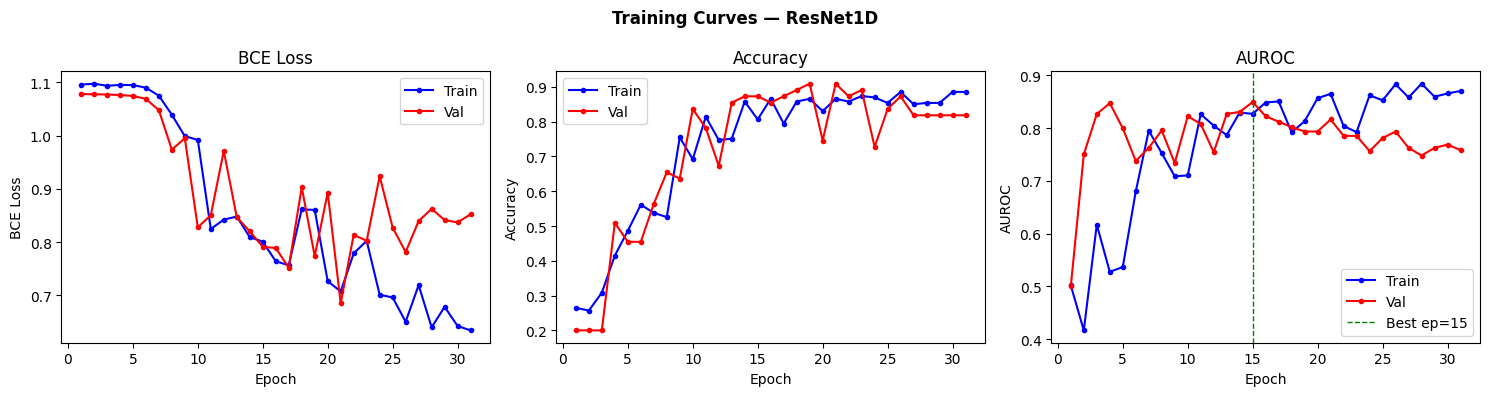

In [26]:
plot_training_curves(history_lstm, save_path=REPORTS / 'training_curves_lstm.png')

In [27]:
class BiLSTM1D(nn.Module):
    def __init__(self, n_leads=12, hidden_size=64, num_layers=2, dropout=0.2, n_classes=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_leads,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True,
            bidirectional=True,
        )
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, 32),  # *2 for bidirectional
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, n_classes),
        )

    def forward(self, x):
        # x shape: [batch, n_leads, n_samples]
        # LSTM expects [batch, seq_len, input_size]
        x = x.transpose(1, 2)  # [batch, n_samples, n_leads]
        lstm_out, _ = self.lstm(x)  # [batch, n_samples, hidden_size * 2]
        lstm_out = lstm_out.transpose(1, 2)  # [batch, hidden_size * 2, n_samples]
        x = self.gap(lstm_out)  # [batch, hidden_size * 2, 1]
        x = x.squeeze(-1)  # [batch, hidden_size * 2]
        return self.head(x)


# Instantiate and dry-run check
bilstm_model = BiLSTM1D(n_leads=cfg.N_LEADS, hidden_size=64, num_layers=2, dropout=0.2).to(DEVICE)
print(f'BiLSTM params: {sum(p.numel() for p in bilstm_model.parameters() if p.requires_grad):,}')

with torch.no_grad():
    dummy = torch.zeros(2, cfg.N_LEADS, cfg.N_SAMPLES).to(DEVICE)
    out = bilstm_model(dummy)
    print(f'Output shape: {out.shape} (expected [2, 1])')

# B3/B4 equivalent for BiLSTM1D
CHECKPOINT_BILSTM = cfg.MODELS_DIR / 'best_bilstm1d.pt'

pos_w = compute_pos_weight(y_train)
criterion_bilstm = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_w, dtype=torch.float32).to(DEVICE)
)

optimizer_bilstm = torch.optim.AdamW(
    bilstm_model.parameters(),
    lr=cfg.LEARNING_RATE,
    weight_decay=cfg.WEIGHT_DECAY,
)

scheduler_bilstm = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_bilstm,
    T_max=cfg.NUM_EPOCHS,
    eta_min=1e-5,
)

print('BiLSTM criterion:', criterion_bilstm)
print('BiLSTM optimizer:', optimizer_bilstm)
print('BiLSTM scheduler: CosineAnnealingLR')

history_bilstm = run_training(
    model=bilstm_model,
    train_loader=loaders['train'],
    val_loader=loaders['val'],
    optimizer=optimizer_bilstm,
    criterion=criterion_bilstm,
    scheduler=scheduler_bilstm,
    device=DEVICE,
    num_epochs=cfg.NUM_EPOCHS,
    patience=cfg.PATIENCE,
    checkpoint_path=CHECKPOINT_BILSTM,
    verbose=True,
)

print(
    f'\nBiLSTM best val AUROC: {max(history_bilstm["val_auroc"]):.4f} '
    f'at epoch {int(np.argmax(history_bilstm["val_auroc"])) + 1}'
)

best_epoch_bilstm = load_checkpoint(CHECKPOINT_BILSTM, bilstm_model)
print(f'Loaded BiLSTM checkpoint from epoch {best_epoch_bilstm}')

y_true_val_bilstm, y_prob_val_bilstm = predict_dl(bilstm_model, loaders['val'], device=DEVICE)
bilstm_metrics_val = compute_metrics(y_true_val_bilstm, y_prob_val_bilstm)
print('\nBiLSTM1D — Val metrics:')
for k, v in bilstm_metrics_val.items():
    print(f'  {k}: {v}')

BiLSTM params: 143,425
Output shape: torch.Size([2, 1]) (expected [2, 1])
BiLSTM criterion: BCEWithLogitsLoss()
BiLSTM optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
BiLSTM scheduler: CosineAnnealingLR
Epoch   1/50 | Train loss=1.0989 acc=0.791 AUROC=0.529 | Val   loss=1.0773 acc=0.800 AUROC=0.700 | 18.4s
Epoch   2/50 | Train loss=1.0963 acc=0.791 AUROC=0.587 | Val   loss=1.0761 acc=0.800 AUROC=0.711 | 17.5s
Epoch   3/50 | Train loss=1.0959 acc=0.794 AUROC=0.520 | Val   loss=1.0748 acc=0.800 AUROC=0.707 | 15.1s
Epoch   4/50 | Train loss=1.0882 acc=0.751 AUROC=0.688 | Val   loss=1.0714 acc=0.855 AUROC=0.719 | 14.0s
Epoch   5/50 | Train loss=1.0853 acc=0.676 AUROC=0.667 | Val   loss=1.0626 acc=0.691 AUROC=0.725 | 17.3s
Epoch   6/50 | Train loss=1

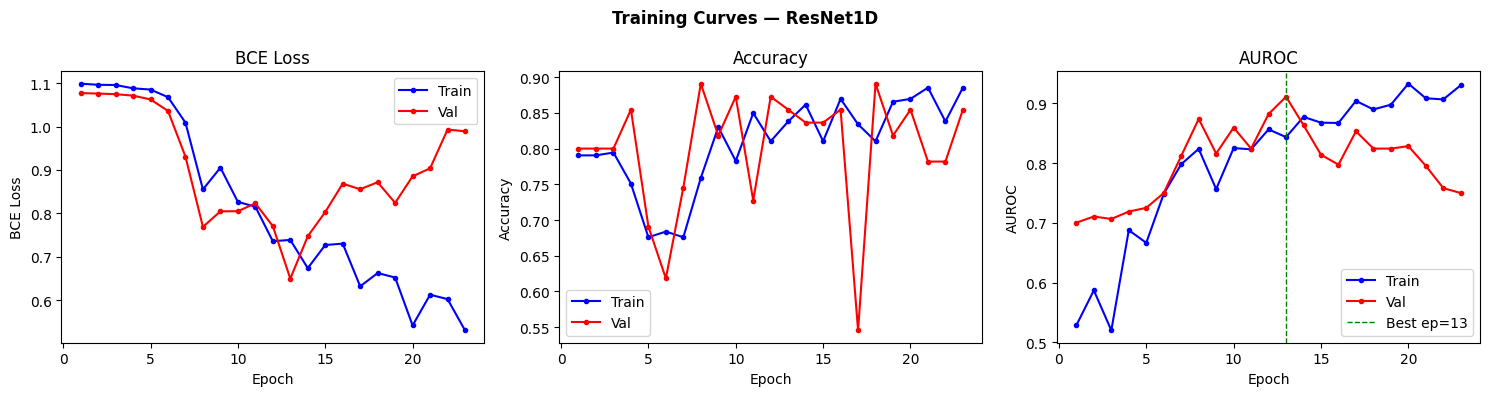

In [28]:
plot_training_curves(history_bilstm, save_path=REPORTS / 'training_curves_bilstm.png')

In [29]:
class RNN1D(nn.Module):
    def __init__(self, n_leads=12, hidden_size=64, num_layers=2, dropout=0.2, n_classes=1):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=n_leads,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True,
        )
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, n_classes),
        )

    def forward(self, x):
        # x shape: [batch, n_leads, n_samples]
        x = x.transpose(1, 2)  # [batch, n_samples, n_leads]
        rnn_out, _ = self.rnn(x)  # [batch, n_samples, hidden_size]
        rnn_out = rnn_out.transpose(1, 2)  # [batch, hidden_size, n_samples]
        x = self.gap(rnn_out)  # [batch, hidden_size, 1]
        x = x.squeeze(-1)  # [batch, hidden_size]
        return self.head(x)


# Instantiate and dry-run check
rnn_model = RNN1D(n_leads=cfg.N_LEADS, hidden_size=64, num_layers=2, dropout=0.2).to(DEVICE)
print(f'RNN params: {sum(p.numel() for p in rnn_model.parameters() if p.requires_grad):,}')

with torch.no_grad():
    dummy = torch.zeros(2, cfg.N_LEADS, cfg.N_SAMPLES).to(DEVICE)
    out = rnn_model(dummy)
    print(f'Output shape: {out.shape} (expected [2, 1])')

# B3/B4 equivalent for RNN1D
CHECKPOINT_RNN = cfg.MODELS_DIR / 'best_rnn1d.pt'

pos_w = compute_pos_weight(y_train)
criterion_rnn = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_w, dtype=torch.float32).to(DEVICE)
)

optimizer_rnn = torch.optim.AdamW(
    rnn_model.parameters(),
    lr=cfg.LEARNING_RATE,
    weight_decay=cfg.WEIGHT_DECAY,
)

scheduler_rnn = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_rnn,
    T_max=cfg.NUM_EPOCHS,
    eta_min=1e-5,
)

print('RNN criterion:', criterion_rnn)
print('RNN optimizer:', optimizer_rnn)
print('RNN scheduler: CosineAnnealingLR')

history_rnn = run_training(
    model=rnn_model,
    train_loader=loaders['train'],
    val_loader=loaders['val'],
    optimizer=optimizer_rnn,
    criterion=criterion_rnn,
    scheduler=scheduler_rnn,
    device=DEVICE,
    num_epochs=cfg.NUM_EPOCHS,
    patience=cfg.PATIENCE,
    checkpoint_path=CHECKPOINT_RNN,
    verbose=True,
)

print(
    f'\nRNN best val AUROC: {max(history_rnn["val_auroc"]):.4f} '
    f'at epoch {int(np.argmax(history_rnn["val_auroc"])) + 1}'
)

best_epoch_rnn = load_checkpoint(CHECKPOINT_RNN, rnn_model)
print(f'Loaded RNN checkpoint from epoch {best_epoch_rnn}')

y_true_val_rnn, y_prob_val_rnn = predict_dl(rnn_model, loaders['val'], device=DEVICE)
rnn_metrics_val = compute_metrics(y_true_val_rnn, y_prob_val_rnn)
print('\nRNN1D — Val metrics:')
for k, v in rnn_metrics_val.items():
    print(f'  {k}: {v}')

RNN params: 15,425
Output shape: torch.Size([2, 1]) (expected [2, 1])
RNN criterion: BCEWithLogitsLoss()
RNN optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
RNN scheduler: CosineAnnealingLR
Epoch   1/50 | Train loss=1.1011 acc=0.209 AUROC=0.458 | Val   loss=1.0819 acc=0.200 AUROC=0.512 | 6.7s
Epoch   2/50 | Train loss=1.0950 acc=0.296 AUROC=0.536 | Val   loss=1.0779 acc=0.200 AUROC=0.560 | 6.9s
Epoch   3/50 | Train loss=1.0966 acc=0.522 AUROC=0.496 | Val   loss=1.0759 acc=0.764 AUROC=0.589 | 6.7s
Epoch   4/50 | Train loss=1.0926 acc=0.660 AUROC=0.563 | Val   loss=1.0747 acc=0.764 AUROC=0.599 | 6.7s
Epoch   5/50 | Train loss=1.0914 acc=0.704 AUROC=0.566 | Val   loss=1.0735 acc=0.764 AUROC=0.587 | 6.8s
Epoch   6/50 | Train loss=1.0830 acc=0.735 AU

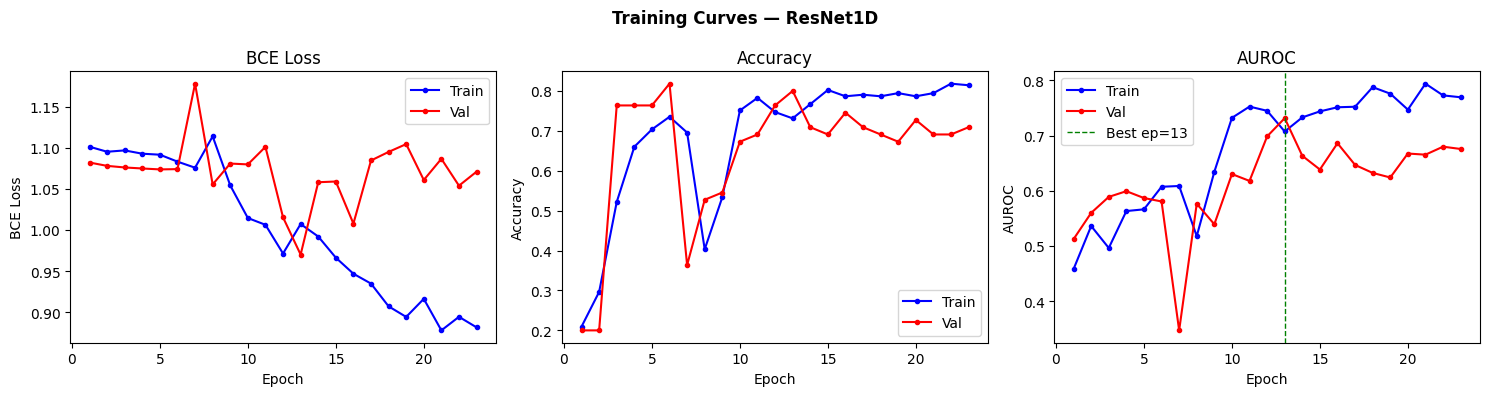

In [30]:
plot_training_curves(history_rnn, save_path=REPORTS / 'training_curves_rnn.png')